In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
from datetime import datetime
from tabulate import tabulate
import matplotlib.pyplot as plt

ValueError: Key backend: 'module://matplotlib_inline.backend_inline' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']

In [1]:
#Data import
clean_segmentation = pd.read_csv('clean_segmentation.csv')
clean_brand_image = pd.read_csv('clean_brand_image.csv')
clean_brand_health = pd.read_csv('clean_brand_health.csv', dtype=str)
clean_companion = pd.read_csv('clean_companion.csv')
clean_competitor = pd.read_csv('clean_competitor.csv')
clean_day_part = pd.read_csv('clean_day_part.csv')
clean_day_of_week = pd.read_csv('clean_day_of_week.csv')
clean_need_state = pd.read_csv('clean_need_state.csv')
clean_sa_var = pd.read_csv('clean_sa_var.csv')
clean_coffee_visit = pd.read_csv('clean_coffee_visit.csv')

NameError: name 'pd' is not defined

In [3]:
#Missing values
dfs = {
    "segmentation": segmentation,
    "brand_image": brand_image,
    "brand_health": brand_health,
    "companion": companion,
    "competitor": competitor,
    "day_part": day_part,
    "week_day": week_day,
    "need_state": need_state,
    "sa_var": sa_var
}

summary_list = []

for name, df in dfs.items():
    temp = pd.DataFrame({
        "Dataset": name,
        "Column": df.columns,
        "Missing Count": df.isnull().sum().values,
        "Missing %": (df.isnull().mean() * 100).values
    })
    summary_list.append(temp)

missing_eda = pd.concat(summary_list)

missing_eda = missing_eda[missing_eda["Missing Count"] > 0]

missing_eda = missing_eda.sort_values(by="Missing %", ascending=False)

missing_eda.reset_index(drop=True, inplace=True)

#Missing severity
def categorize_missing(p):
    if p > 50:
        return "High"
    elif p > 10:
        return "Medium"
    elif p > 0:
        return "Low"
    else:
        return "None"

missing_eda["Severity"] = missing_eda["Missing %"].apply(categorize_missing)

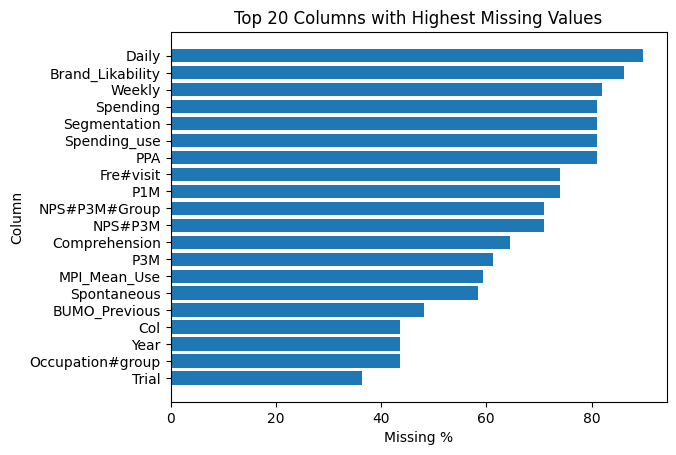

In [4]:
# Top 20 most missing columns
top_missing = missing_eda.head(20)

plt.figure()
plt.barh(top_missing["Column"], top_missing["Missing %"])
plt.xlabel("Missing %")
plt.ylabel("Column")
plt.title("Top 20 Columns with Highest Missing Values")
plt.gca().invert_yaxis()
plt.show()

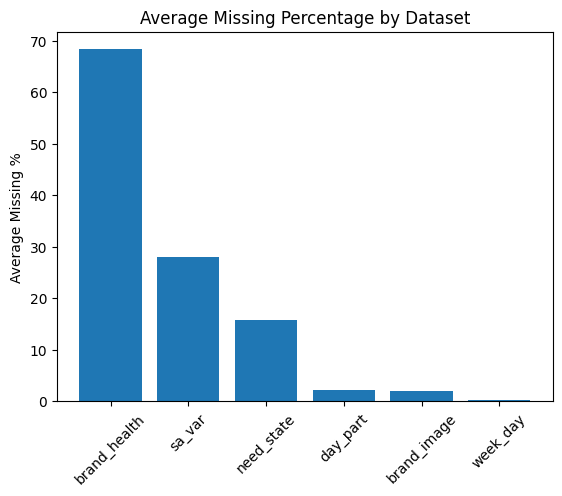

In [5]:
#Missing values by dataset
dataset_missing = missing_eda.groupby("Dataset")["Missing %"].mean().sort_values(ascending=False)

plt.figure()
plt.bar(dataset_missing.index, dataset_missing.values)
plt.xticks(rotation=45)
plt.ylabel("Average Missing %")
plt.title("Average Missing Percentage by Dataset")
plt.show()